# World population distribution

This dataset contains the `population` for each world `region` from 1800 through 2100 (projected).

The four regions are defined by Gapminder.org. The regions are Africa, Asia, Europe, and the Americas.

This csv also contains global data (`region` is 'world') and other indicators including `life_expectancy`, `child_mortality` rates (per 1000), average number of `babies_per_woman`, and average `income_per_person` (in adjusted USD). See the README for details.

In [1]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'world-indicators.csv'.

# from google.colab import files
# uploaded = files.upload()

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

indicators = pd.read_csv('world-indicators.csv')
indicators.head()

,year,region,population,life_expectancy,child_mortality,babies_per_woman,income_per_person
0,1800,africa,81209567,30.091575,443.51,6.58,437.699298
1,1801,africa,81313551,30.016479,443.47,6.58,437.322912
2,1802,africa,81418900,30.019117,443.44,6.58,436.949999
3,1803,africa,81525621,30.099188,443.41,6.58,436.501460
4,1804,africa,81633731,30.101720,443.37,6.58,436.033849


### Project Ideas

#### Horizontal Bar plot

- In the `year` 2000, there were roughly 6 billion people on earth. If you had blocks that each represented 1 billion people, how many blocks would you predict belong in each `region` (africa, asia, europe, americas)?

- In the `year` 2100, the UN projects 11 billion people. Again, predict how many blocks would now go to each `region`.

- Test your predictions. First create a new column named `pop_billions` (`population` divided by 1e9 that is rounded to the nearest would number).

- Then filter on the years 2000 and 2100 to create your horizontal bar plots. 

- Follow the Pro Tips for horizontal bar plots.

Challenge: Place your plots side by side by using `plt.subplots(1,2)`.

#### Line Plot

- Create a line plot with year on the x-axis and population on y-axis for each `region`.

- We pivoted the dataframe for you in the variable `df_pivot`.

- Follow the Pro Tips for line plots.



In [14]:
# quick data cleaning
df = indicators[['year', 'region', 'population']]   # select columns of interest
df = df.query('region != "world"')  # only include 4 regions
df.head()

,year,region,population
0,1800,africa,81209567
1,1801,africa,81313551
2,1802,africa,81418900
3,1803,africa,81525621
4,1804,africa,81633731


In [15]:
# Pivot the DataFrame for the line plot
df_pivot = df.pivot(index='year', columns='region', values='population').reset_index()
df_pivot.columns.name = None  # remove index name
df_pivot.head()

,year,africa,americas,asia,europe
0,1800,81209567,23556679,672521875,206910570
1,1801,81313551,23817319,674654640,207842812
2,1802,81418900,24087376,676807276,208785186
3,1803,81525621,24367066,678979750,209737823
4,1804,81633731,24656605,681172043,210700861


In [4]:
def add_end_labels(df, x, column_names, alpha=1, fontweight='normal'):
    for column_name in column_names:
        y = df[column_name].iloc[-1]
        label = f'  {column_name}'
        plt.text(x, y, label, va="center", alpha=alpha, fontweight=fontweight)

In [ ]:
# create a column rounded to nearest whole number
indicators['pop_billions'] = (indicators['population']/1e9).round()

# filter out the world region nd select years 2000 and 2100
df_filtered = indicators[indicators['region']  != 'world']
df_2000 = df_filtered[df_filtered['year'] == 2000]
df_2100 = df_filtered[df_filtered['year'] == 2100]

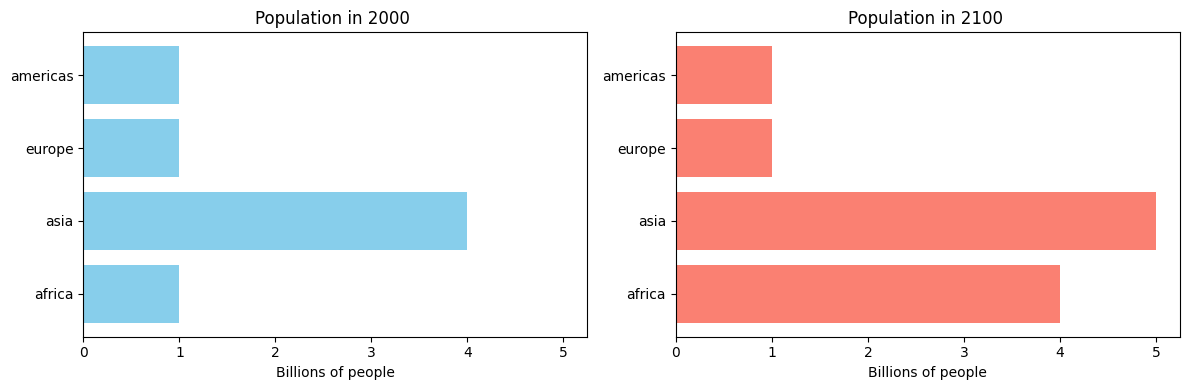

In [11]:
# side by side horizontal bar plots 
fig, axes = plt.subplots(1,2, figsize=(12,4), sharex=True)

# plot 2000
axes[0].barh(df_2000['region'], df_2000['pop_billions'], color='skyblue')
axes[0].set_title("Population in 2000 ")
axes[0].set_xlabel("Billions of people")

# plot 2100
axes[1].barh(df_2100['region'], df_2100['pop_billions'], color='salmon')
axes[1].set_title("Population in 2100 ")
axes[1].set_xlabel("Billions of people")

plt.tight_layout()
plt.show()

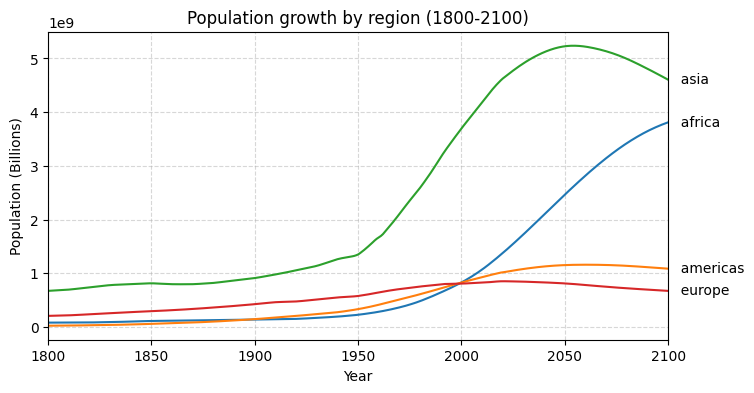

In [17]:
plt.figure(figsize=(8,4))

regions = ['africa', 'americas', 'asia', 'europe']

# plot each region's population line
for region in regions:
    plt.plot(df_pivot['year'], df_pivot[region], label=region)
    
add_end_labels(df_pivot, x=2102, column_names=regions)

plt.title('Population growth by region (1800-2100)')
plt.xlabel('Year')
plt.ylabel('Population (Billions)')
plt.xlim(1800,2100)   #extend x-axis slightly so end labels fit nicely
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

- The change in population drastically rise from 1950-2050 but it shows a decrease till 2100